## Scenario analysis results comparison

#### Imports

In [15]:
# pandas for data manipulation
# re for regular expressions
import re

# pyplot for plotting
# numpy for numerical operations
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# other .py files
from utils.csv_import_data_analysis import get_csv_files_generalistic, sort_meta_info

In [16]:
# Retrieve CSV files

path_to: str = "C:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project"
path: str = path_to + "\\new_data"

# scenario -> user -> activity -> esp -> trial -> list[file_path]
FileMap = dict[str, dict[str, dict[str, dict[str, dict[str, list[str]]]]]]
# scenario -> user -> activity -> esp -> trial -> csi ndarray
csi_map = dict[str, dict[str, dict[str, dict[str, dict[str, np.ndarray]]]]]


data_files = get_csv_files_generalistic(path)
scenarios_id, users_id, activities_id, esps_id, trials_id = sort_meta_info(path)
print(f"Scenarios:  {scenarios_id}")
print(f"Users:      {users_id}")
print(f"Activities: {activities_id}")
print(f"ESPs: \t    {esps_id}")
print(f"Trials:     {trials_id}")
print("\nData files: ", data_files)


Scenarios:  ['21', '22']
Users:      ['00', '01']
Activities: ['00', '01']
ESPs: 	    ['01', '02', '04', '05', '06', '07']
Trials:     ['01', '02', '03', '04']

Data files:  {'scenario_21': {'user_00': {'activity_00': {'esp_01': {'trial_01': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/21_00_00_01_01_2026-03-05_15-30.csv')], 'trial_02': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/21_00_00_01_02_2026-03-09_14-24.csv')], 'trial_03': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/21_00_00_01_03_2026-03-09_15-05.csv')], 'trial_04': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/21_00_00_01_04_2026-03-09_16-24.csv')]}, 'esp_02': {'trial_01': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabal

#### Functions 
 - calibrate magnitude
 - apply pca
 - process csi
 - process magnitude

In [17]:
# Per-packet normalization to mitigate AGC effects.
# magnitude shape: (n_samples, n_subcarriers)

# antes de sacar o AGC (5 GHz)
def calibrate_magnitude(magnitude: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(magnitude, axis=1, keepdims=True)
    norm[norm == 0] = 1  # avoid division by zero
    return magnitude / norm


def apply_pca(magnitude_data, variance_ratio=0.999):
    pca = PCA(n_components=variance_ratio)
    transformed = pca.fit_transform(magnitude_data)
    return transformed, pca


def process_csi(data_file: str, its5ghz: bool) -> np.ndarray:
    file_csv = pd.read_csv(data_file, header=None)

    # number of samples
    if its5ghz:
        print("Com 5 GHz")
        csi_raw: pd.Series = file_csv.iloc[:, 14]
    else:
        csi_raw: pd.Series = file_csv.iloc[:, 25]

    total_sc_2_4_GHz: int = 128
    total_sc_5_GHz: int = 106
    valid_csi: list[list[float]] = []

    # contar CSI invÃ¡lidos
    no_match_count: int = 0
    no_complete_count: int = 0

    if its5ghz:
        for entry in csi_raw:
            match = re.search(r"\[(.*?)\]", str(entry))
            if not match:
                no_match_count += 1
                continue

            nums = [float(n) for n in re.findall(r"-?\d+", match.group(1))]

            # para jÃ¡ hard coded, mas para mudar
            if len(nums) in [104, 106]:
                valid_csi.append(nums)
            else:
                no_complete_count += 1

    else:
        for entry in csi_raw:
            match = re.search(r"\[(.*?)\]", str(entry))
            if not match:
                no_match_count += 1
                continue

            nums = [float(n) for n in re.findall(r"-?\d+", match.group(1))]

            if len(nums) == total_sc_2_4_GHz:
                valid_csi.append(nums)
            else:
                no_complete_count += 1

    valid_csi = np.array(valid_csi)

    print(f"Total CSI entries: {len(csi_raw)}")
    print(f"Valid CSI entries: {len(valid_csi)}")
    print(f"Invalid CSI entries (no match): {no_match_count}")
    print(f"Invalid CSI entries (incomplete): {no_complete_count}")
    print("Valid CSI shape: ", valid_csi.shape, "\n")

    # (n_amostras, 128)
    complex_csi = valid_csi[:, ::2] + 1j * valid_csi[:, 1::2]

    # coloca sc DC no centro (index 32)
    fft_csi = np.fft.fftshift(complex_csi, axes=1)

    # Extract the 52 active subcarriers (IEEE 802.11n standard): [6:58]
    # (n_amostras, 52)
    active_sc = fft_csi[:, 6:58]

    # Remove subcarriers at positions 25, 26, 27 (center)
    # (n_amostras, 49)
    active_sc = np.delete(active_sc, [25, 26, 27], axis=1)

    # seleciona sub_carriers: 2 a 47
    active_sc = active_sc[:, 2:48]

    return np.abs(active_sc)


def process_magnitude(data_files: FileMap) -> csi_map:
    magnitudes = {}

    for scenario_key, users_map in data_files.items():
        print(f"Processing scenario: {scenario_key}")
        magnitudes[scenario_key] = {}

        its5ghz = ("22" in scenario_key or "12" in scenario_key)

        for user_key, activities_map in users_map.items():
            magnitudes[scenario_key][user_key] = {}

            for activity_key, esps_map in activities_map.items():
                magnitudes[scenario_key][user_key][activity_key] = {}

                for esp_key, trials_map in esps_map.items():
                    magnitudes[scenario_key][user_key][activity_key][esp_key] = {}

                    for trial_key, file_paths in trials_map.items():
                        if file_paths is None:
                            continue

                        # Keep first timestamp file for each trial key
                        path = file_paths[0] if isinstance(file_paths, list) else file_paths
                        magnitudes[scenario_key][user_key][activity_key][esp_key][
                            trial_key
                        ] = process_csi(str(path), its5ghz)

    return magnitudes


In [18]:
magnitude_data = process_magnitude(data_files)

Processing scenario: scenario_21
Total CSI entries: 190
Valid CSI entries: 150
Invalid CSI entries (no match): 40
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (150, 128) 

Total CSI entries: 307
Valid CSI entries: 219
Invalid CSI entries (no match): 88
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (219, 128) 

Total CSI entries: 391
Valid CSI entries: 304
Invalid CSI entries (no match): 87
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (304, 128) 

Total CSI entries: 626
Valid CSI entries: 477
Invalid CSI entries (no match): 149
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (477, 128) 

Total CSI entries: 247
Valid CSI entries: 189
Invalid CSI entries (no match): 58
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (189, 128) 

Total CSI entries: 358
Valid CSI entries: 269
Invalid CSI entries (no match): 89
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (269, 128) 

Total CSI entries: 535
Valid CSI entries: 443
Invalid CSI entries (no match): 

Total CSI entries: 272
Valid CSI entries: 176
Invalid CSI entries (no match): 96
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (176, 128) 

Total CSI entries: 337
Valid CSI entries: 299
Invalid CSI entries (no match): 38
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (299, 128) 

Total CSI entries: 622
Valid CSI entries: 416
Invalid CSI entries (no match): 206
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (416, 128) 

Total CSI entries: 934
Valid CSI entries: 674
Invalid CSI entries (no match): 260
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (674, 128) 

Total CSI entries: 496
Valid CSI entries: 354
Invalid CSI entries (no match): 142
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (354, 128) 

Total CSI entries: 420
Valid CSI entries: 329
Invalid CSI entries (no match): 91
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (329, 128) 

Total CSI entries: 549
Valid CSI entries: 420
Invalid CSI entries (no match): 129
Invalid CSI entries (incomp

#### Magnitude comparison by 3D graph

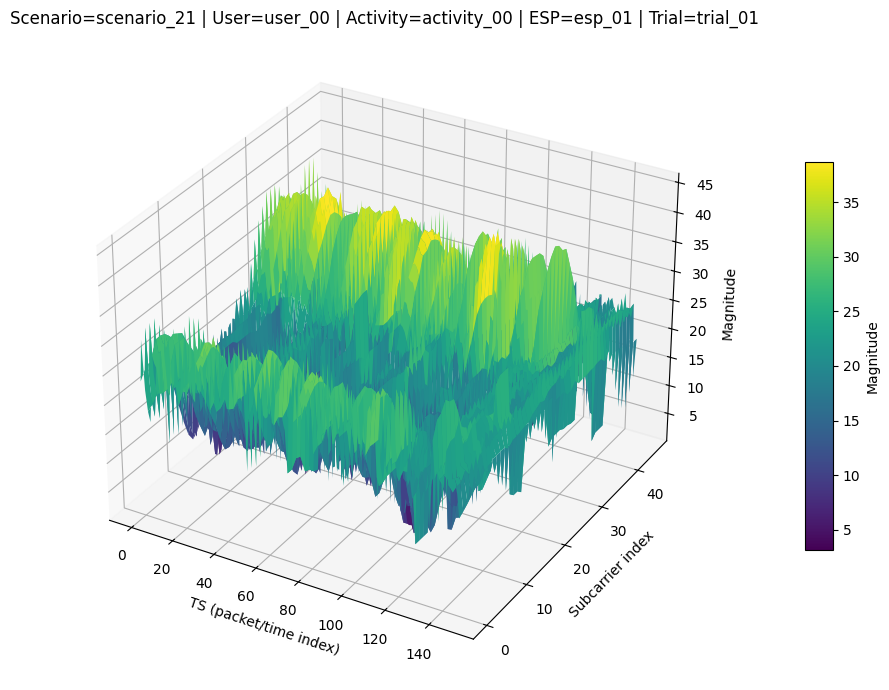

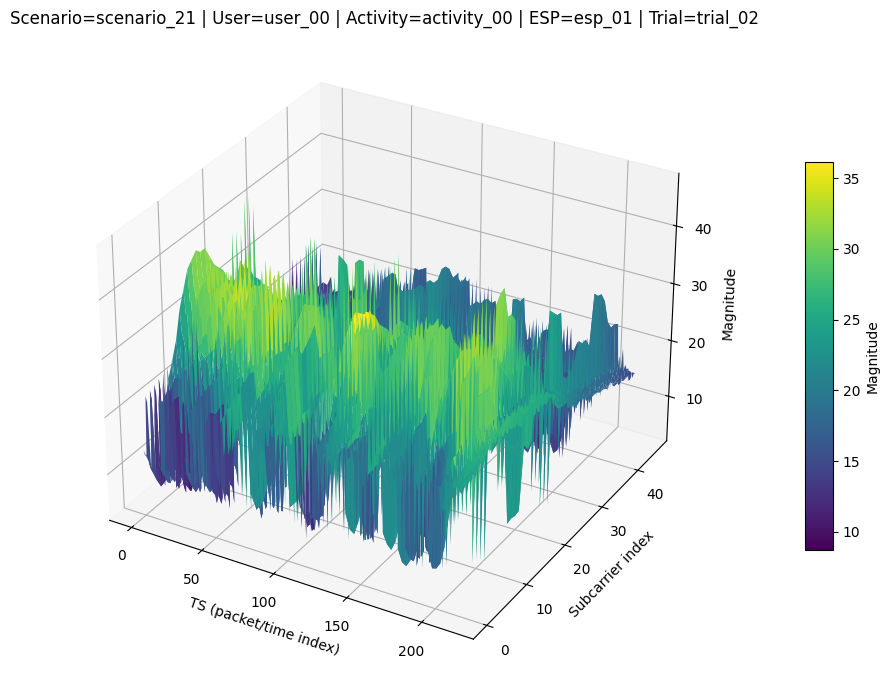

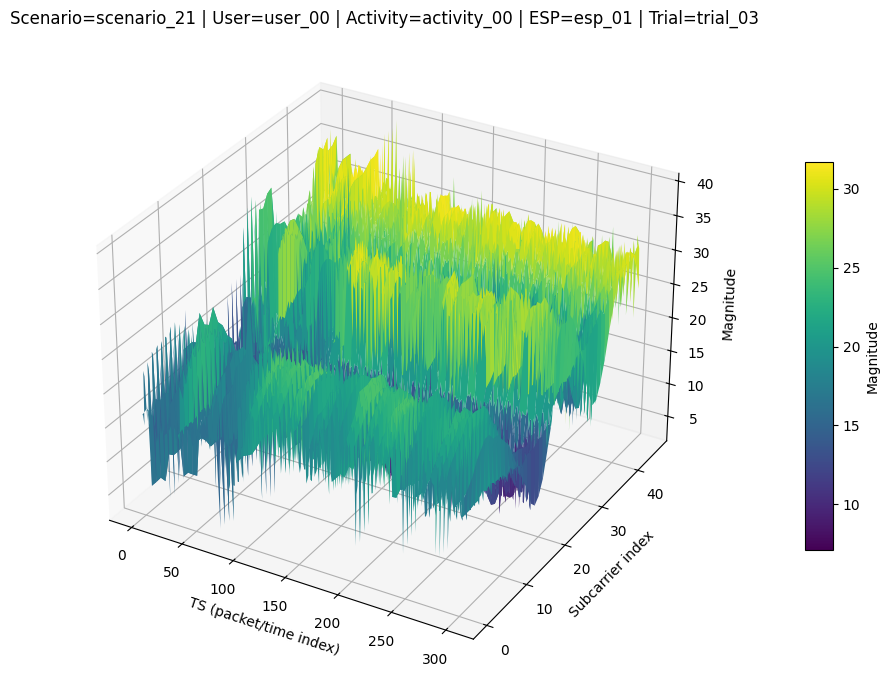

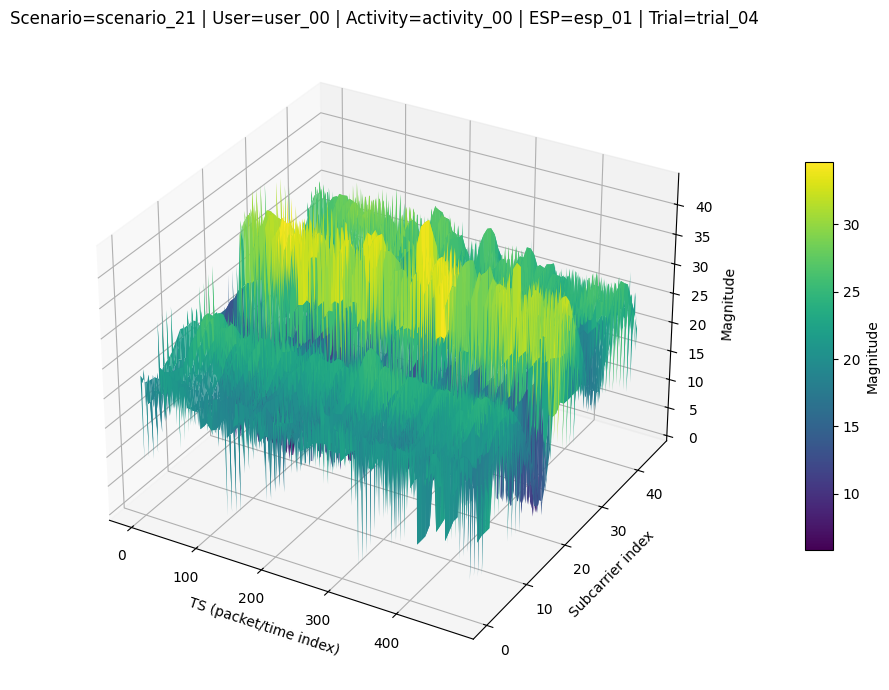

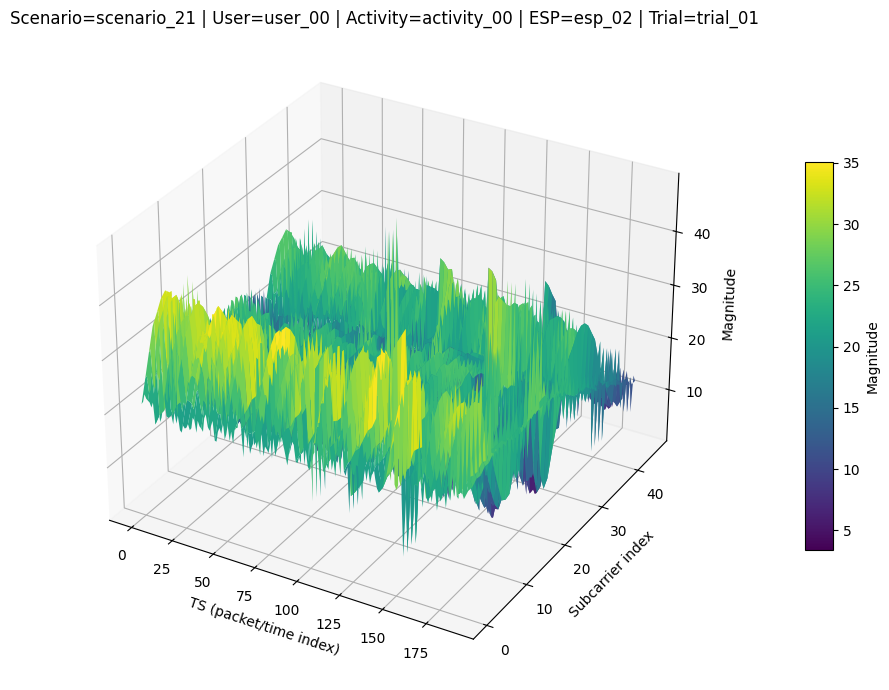

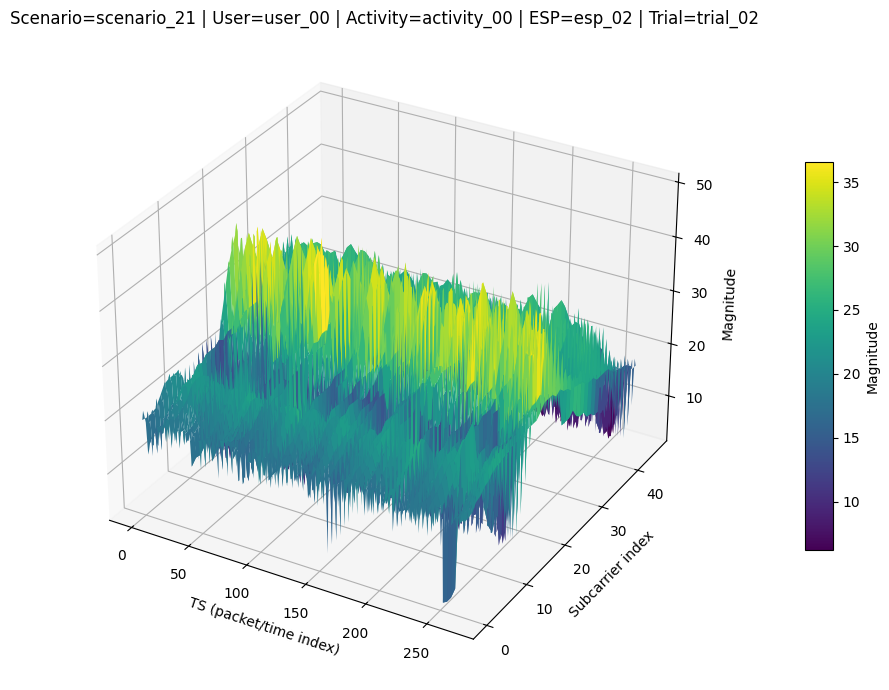

Stopped after 6 plots (max_plots reached).


In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)


def plot_csi_magnitude_3d(
    magnitude: np.ndarray,
    title: str,
    cmap: str = "viridis",
    figsize: tuple[int, int] = (10, 7),
) -> None:
    """Draw a 3D surface with axes: TS (time sample), Subcarrier, magnitude."""
    if magnitude.size == 0:
        print(f"[SKIP] Empty magnitude matrix for: {title}")
        return

    n_ts, n_esop = magnitude.shape
    ts = np.arange(n_ts)
    esop = np.arange(n_esop)

    # Build a grid aligned with magnitude shape: (TS, ESOP).
    ts_grid, esop_grid = np.meshgrid(ts, esop, indexing="ij")

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")
    surface = ax.plot_surface(
        ts_grid,
        esop_grid,
        magnitude,
        cmap=cmap,
        linewidth=0,
        antialiased=True,
    )

    ax.set_xlabel("TS (packet/time index)")
    ax.set_ylabel("Subcarrier index")
    ax.set_zlabel("Magnitude")
    ax.set_title(title)
    fig.colorbar(surface, shrink=0.6, aspect=14, pad=0.1, label="Magnitude")
    plt.tight_layout()
    plt.show()


def draw_3d_graphs_for_all_files(
    magnitude_data: csi_map,
    max_plots: int | None = None,
    scenarios: set[str] | None = None,
    users: set[str] | None = None,
    activities: set[str] | None = None,
    esps: set[str] | None = None,
    trials: set[str] | None = None,
) -> None:
    plotted = 0

    for scenario_key, users_map in magnitude_data.items():
        if scenarios is not None and scenario_key not in scenarios:
            continue

        for user_key, activities_map in users_map.items():
            if users is not None and user_key not in users:
                continue

            for activity_key, esps_map in activities_map.items():
                if activities is not None and activity_key not in activities:
                    continue

                for esp_key, trials_map in esps_map.items():
                    if esps is not None and esp_key not in esps:
                        continue

                    for trial_key, magnitude in trials_map.items():
                        if trials is not None and trial_key not in trials:
                            continue

                        title = (
                            f"Scenario={scenario_key} | User={user_key} | "
                            f"Activity={activity_key} | ESP={esp_key} | Trial={trial_key}"
                        )
                        plot_csi_magnitude_3d(magnitude, title=title)

                        plotted += 1
                        if max_plots is not None and plotted >= max_plots:
                            print(f"Stopped after {plotted} plots (max_plots reached).")
                            return

    print(f"Finished plotting {plotted} file(s).")


# Example usage (recommended first run with a limit):
draw_3d_graphs_for_all_files(magnitude_data, max_plots=6)

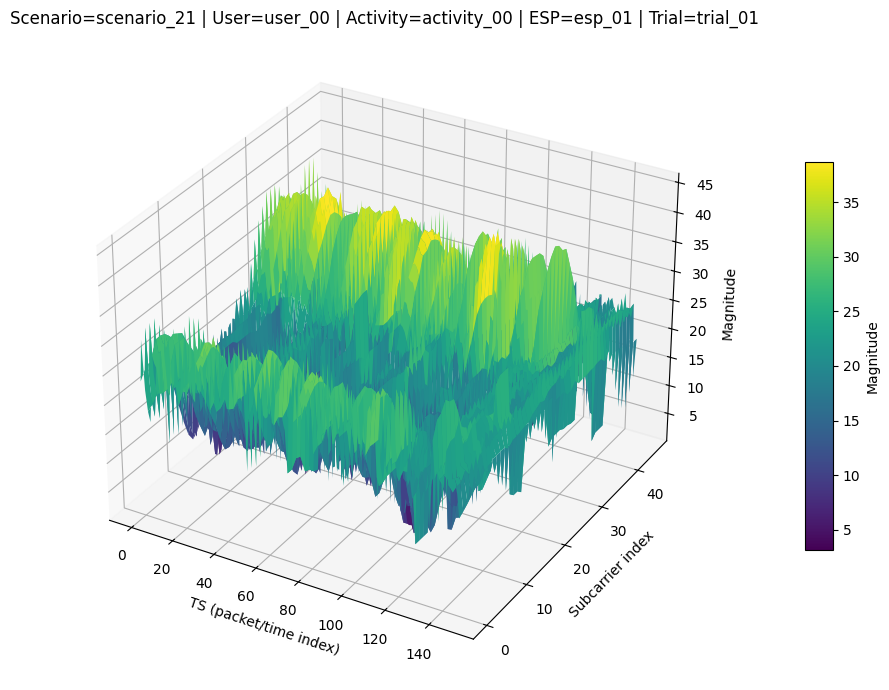

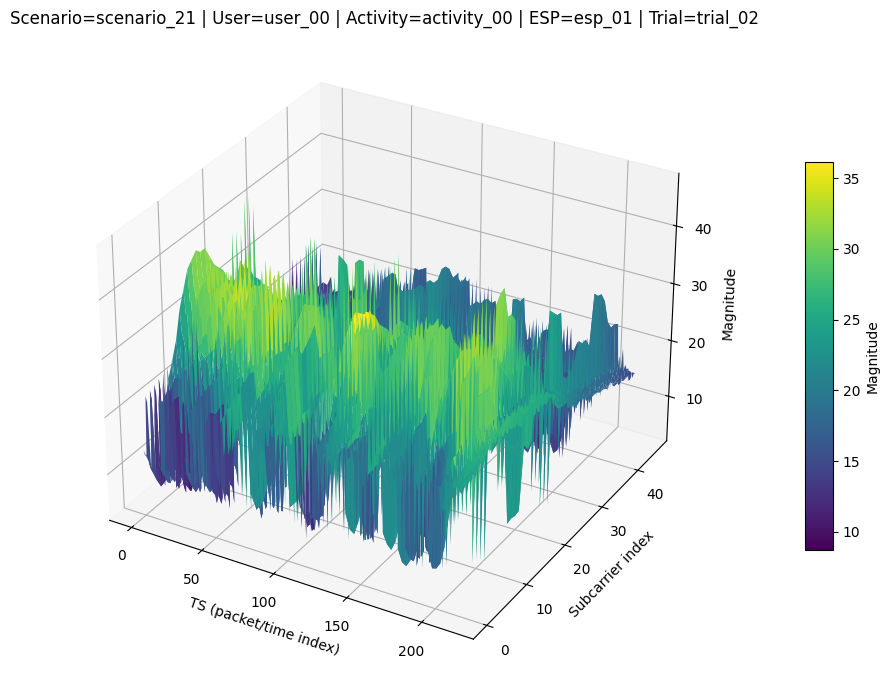

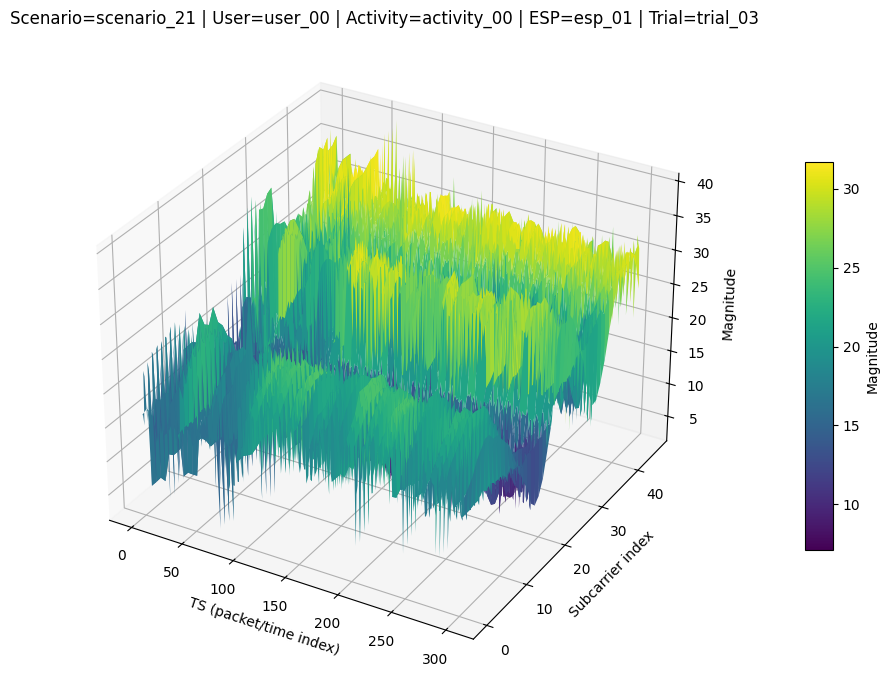

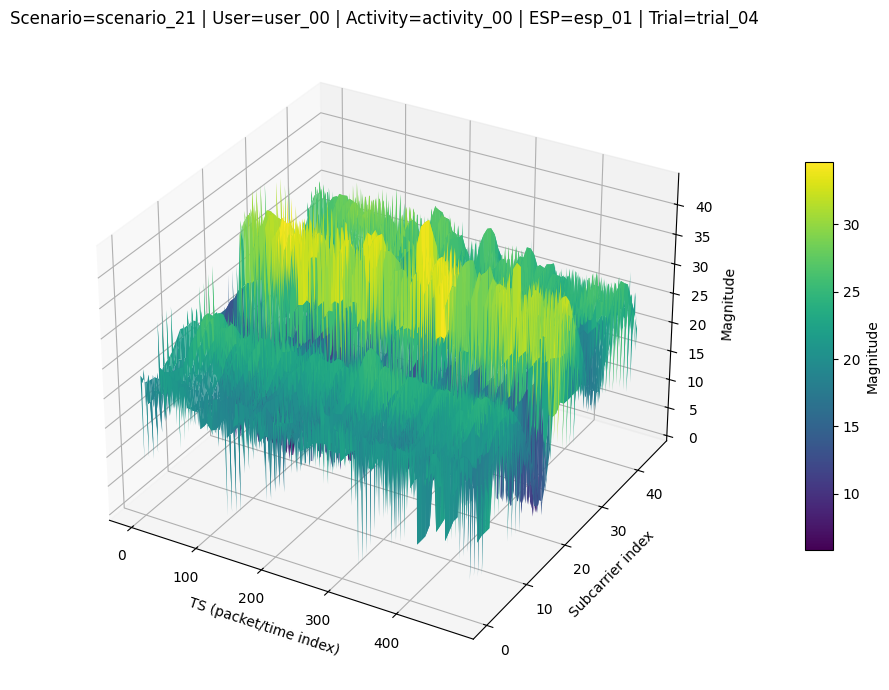

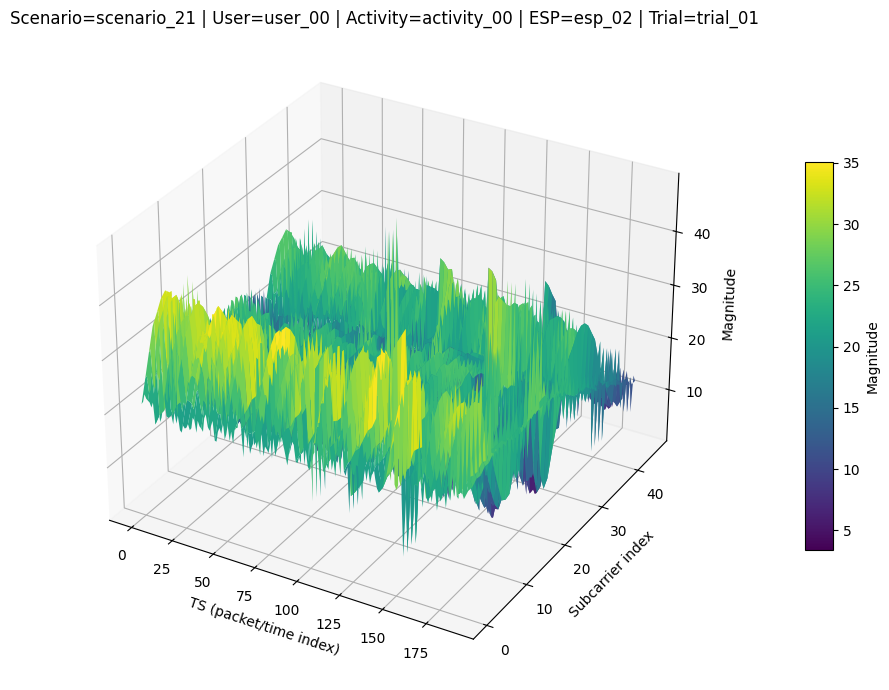

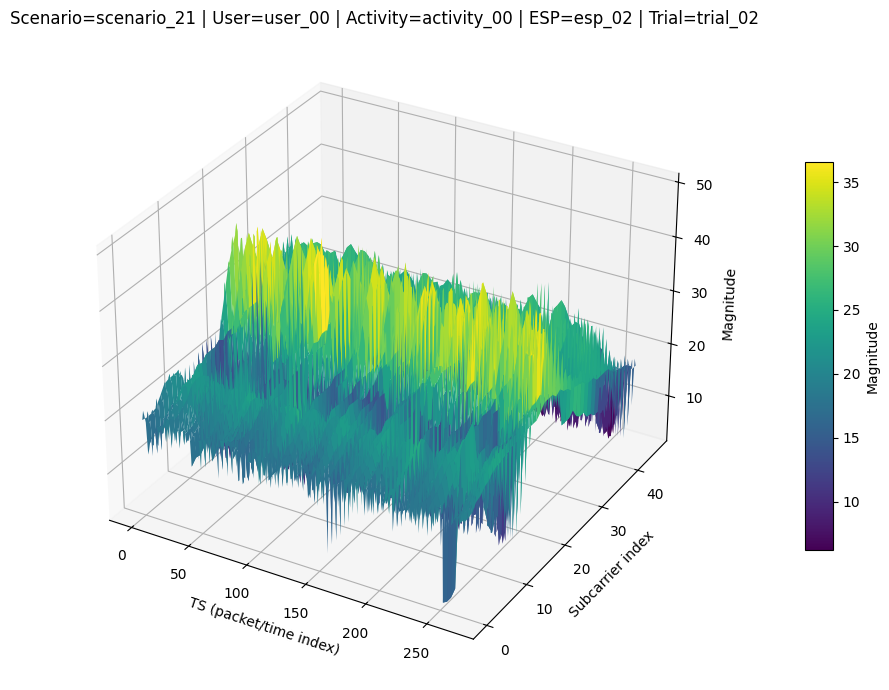

Stopped after 6 plots (max_plots reached).


In [20]:

# Example usage (recommended first run with a limit):
draw_3d_graphs_for_all_files(magnitude_data, max_plots=6)

#### Dateset setup
 - segment signal
 - process raw magnitude
 - process pca features
 - build scnenario dataset

In [21]:
def segment_signal(
    signal: np.ndarray,
    window_size: int,
    overlap: int,
) -> list[np.ndarray]:

    if overlap >= window_size:
        raise ValueError("Overlap must be less than window size")

    step = window_size - overlap
    segments: list[np.ndarray] = []

    for i in range(0, signal.shape[0] - window_size + 1, step):
        segments.append(signal[i : i + window_size])

    return segments


def process_pipeline_raw_magnitude(
    csi_magnitude: np.ndarray, window_size: int = 10, overlap_size: int = 2,
) -> np.ndarray:
    csi_magnitude = calibrate_magnitude(csi_magnitude)

    segmented_data = segment_signal(csi_magnitude, window_size, overlap_size)

    # Extract features per window
    features = []
    for window_data in segmented_data:
        # Flatten window to compute scalar statistics
        flat_window = window_data.flatten()
        features.append([
            np.mean(flat_window),
            np.std(flat_window),
            np.max(flat_window),
            np.var(flat_window),
            np.sum(flat_window ** 2),
        ])

    return np.array(features)  # shape: (n_windows, 5)


def process_pipeline_pca_features(
    csi_magnitude: np.ndarray, window_size: int = 10, overlap_size: int = 2,
) -> np.ndarray:
    csi_magnitude = calibrate_magnitude(csi_magnitude)

    pca_features, _ = apply_pca(csi_magnitude, variance_ratio=0.999)

    segmented_data = segment_signal(pca_features, window_size, overlap_size)

    # Extract features per window from first PCA component
    features = []
    for window_data in segmented_data:
        # Extract first PCA component only, then flatten
        pc1_data = window_data[:, 0]
        features.append([
            np.var(pc1_data),
            np.std(pc1_data),
            np.sum(pc1_data ** 2),
        ])

    return np.array(features)  # shape: (n_windows, 3)


def process_pipeline(
    csi_magnitude: np.ndarray, window_size: int = 10, overlap_size: int = 2,
) -> np.ndarray:
    csi_magnitude = calibrate_magnitude(csi_magnitude)

    pca_features, _ = apply_pca(csi_magnitude, variance_ratio=0.999)

    segmented_data = segment_signal(pca_features, window_size, overlap_size)

    # Extract features per window from first PCA component
    features = []
    for window_data in segmented_data:
        # Extract first PCA component only, then flatten
        pc1_data = window_data[:, 0]
        features.append([
            np.var(pc1_data),
            np.std(pc1_data),
            np.sum(pc1_data ** 2),
        ])

    return np.array(features)  # shape: (n_windows, 3)


def build_scenario_dataset(
    users_map: dict[str, dict[str, dict[str, dict[str, np.ndarray]]]],
    scenario_key: str,
    feature_type: str = "pca_all",
    window_size: int = 10,
    overlap_size: int = 2,
) -> pd.DataFrame:

    rows: list[dict[str, object]] = []

    # Select appropriate pipeline based on feature_type
    if feature_type == "raw":
        pipeline_func = process_pipeline_raw_magnitude
        feature_prefix_list = ["mean", "std", "max", "variance", "energy"]
    elif feature_type == "pca":
        pipeline_func = process_pipeline_pca_features
        feature_prefix_list = ["pc1_variance", "pc1_std", "pc1_energy"]
    else:  # pca_all
        pipeline_func = process_pipeline
        feature_prefix_list = ["variance", "std", "energy"]

    # Process each (user, activity, trial) combination
    for user_key, activities_map in users_map.items():
        for activity_key, esps_map in activities_map.items():
            # Identify trials available across all ESPs
            trial_sets = []
            for esp_key, trials_map in esps_map.items():
                trial_sets.append(set(trials_map.keys()))

            if len(trial_sets) == 0:
                print(f"[WARN] No ESP/trial data for {scenario_key}/{user_key}/{activity_key}")
                continue

            common_trials = sorted(set.intersection(*trial_sets))
            if len(common_trials) == 0:
                print(
                    f"[WARN] No common trials across ESPs for {scenario_key}/{user_key}/{activity_key}"
                )
                continue

            for trial_key in common_trials:
                print(
                    f"Processing: {scenario_key} | {user_key} | {activity_key} | {trial_key} | Fusing ESPs | Feature Type: {feature_type}",
                )

                # Group by trial so each recording trial is isolated in splitting
                group_id = f"{scenario_key}_{user_key}_{activity_key}_{trial_key}"

                # Step 1: Compute window features for each ESP separately (same trial)
                esp_features = {}
                for esp_key, trials_map in esps_map.items():
                    csi = trials_map.get(trial_key)
                    if csi is None:
                        continue

                    print(f"  Computing features for {esp_key} @ {trial_key}")
                    window_features = pipeline_func(csi, window_size, overlap_size)
                    esp_features[esp_key] = window_features

                if len(esp_features) == 0:
                    print(f"  [WARN] No ESP features for {user_key}/{activity_key}/{trial_key}")
                    continue

                # Step 2: Find minimum number of windows across all ESPs
                min_windows = min(features.shape[0] for features in esp_features.values())

                if min_windows == 0:
                    print(
                        f"  [WARN] No valid windows for {user_key}/{activity_key}/{trial_key}, skipping"
                    )
                    continue

                print(f"  Aligning to {min_windows} windows across {len(esp_features)} ESPs")

                # Step 3: Truncate all ESPs to common window count
                aligned_features = {}
                for esp_key, features in esp_features.items():
                    aligned_features[esp_key] = features[:min_windows, :]

                # Step 4: Concatenate features from all ESPs horizontally
                sorted_esp_keys = sorted(aligned_features.keys())
                fused_features = np.concatenate(
                    [aligned_features[esp_key] for esp_key in sorted_esp_keys],
                    axis=1,
                )

                print(f"  Fused feature shape: {fused_features.shape}")

                # Step 5: Create rows with fused features
                feature_names = []
                for esp_key in sorted_esp_keys:
                    for feat_prefix in feature_prefix_list:
                        feature_names.append(f"{feat_prefix}_{esp_key}")

                for window_idx in range(min_windows):
                    row = {
                        "scenario": scenario_key,
                        "user": user_key,
                        "activity": activity_key,
                        "trial": trial_key,
                        "group_id": group_id,
                        "window_idx": window_idx,
                    }
                    for feat_idx, feat_name in enumerate(feature_names):
                        row[feat_name] = fused_features[window_idx, feat_idx]

                    rows.append(row)

    scenario_df = pd.DataFrame(rows)

    if scenario_df.empty:
        print(f"[WARN] Empty dataset for scenario {scenario_key}")
        return scenario_df

    # Add label column: activity "00" -> 0, activity "01" -> 1
    activity_to_label = {
        "activity_00": 0,
        "activity_01": 1,
    }
    scenario_df["label"] = scenario_df["activity"].map(activity_to_label)

    print(f"Final dataset: {scenario_df.shape[0]} rows x {scenario_df.shape[1]} columns")
    print(f"Number of unique groups (files/sessions): {scenario_df['group_id'].nunique()}\n")

    return scenario_df


In [22]:
# Build two types of datasets per scenario: raw magnitude features and PCA features
dataset_per_scenario_raw: dict[str, pd.DataFrame] = {}
dataset_per_scenario_pca: dict[str, pd.DataFrame] = {}
dataset_per_scenario: dict[str, pd.DataFrame] = {}  # Keep original for compatibility

for scenario_key, users_map in magnitude_data.items():
    print(f"\n{'=' * 80}")
    print(f"Building datasets for scenario {scenario_key}")
    print(f"{'=' * 80}\n")

    # Raw magnitude features dataset
    print("--- RAW MAGNITUDE FEATURES ---")
    dataset_per_scenario_raw[scenario_key] = build_scenario_dataset(
        users_map, scenario_key, feature_type="raw",
    )
    print(
        f"Scenario {scenario_key} (Raw): {dataset_per_scenario_raw[scenario_key].shape[0]} windows (features + labels)\n",
    )

    # PCA features dataset
    print("--- PCA FEATURES ---")
    dataset_per_scenario_pca[scenario_key] = build_scenario_dataset(
        users_map, scenario_key, feature_type="pca",
    )
    print(
        f"Scenario {scenario_key} (PCA): {dataset_per_scenario_pca[scenario_key].shape[0]} windows (features + labels)\n",
    )

    # Original all-PCA features for backward compatibility
    print("--- ORIGINAL ALL-PCA FEATURES ---")
    dataset_per_scenario[scenario_key] = build_scenario_dataset(
        users_map, scenario_key, feature_type="pca_all",
    )
    print(
        f"Scenario {scenario_key} (All-PCA): {dataset_per_scenario[scenario_key].shape[0]} windows (features + labels)\n",
    )

scenario_keys = sorted(dataset_per_scenario.keys())

# Create explicit variables for up to 2 scenarios found in the data
dataset_1 = (
    dataset_per_scenario[scenario_keys[0]] if len(scenario_keys) > 0 else pd.DataFrame()
)
dataset_2 = (
    dataset_per_scenario[scenario_keys[1]] if len(scenario_keys) > 1 else pd.DataFrame()
)

# Also create for raw and PCA versions
dataset_1_raw = (
    dataset_per_scenario_raw[scenario_keys[0]] if len(scenario_keys) > 0 else pd.DataFrame()
)
dataset_2_raw = (
    dataset_per_scenario_raw[scenario_keys[1]] if len(scenario_keys) > 1 else pd.DataFrame()
)

dataset_1_pca = (
    dataset_per_scenario_pca[scenario_keys[0]] if len(scenario_keys) > 0 else pd.DataFrame()
)
dataset_2_pca = (
    dataset_per_scenario_pca[scenario_keys[1]] if len(scenario_keys) > 1 else pd.DataFrame()
)



Building datasets for scenario scenario_21

--- RAW MAGNITUDE FEATURES ---
Processing: scenario_21 | user_00 | activity_00 | trial_01 | Fusing ESPs | Feature Type: raw
  Computing features for esp_01 @ trial_01
  Computing features for esp_02 @ trial_01
  Computing features for esp_04 @ trial_01
  Aligning to 18 windows across 3 ESPs
  Fused feature shape: (18, 15)
Processing: scenario_21 | user_00 | activity_00 | trial_02 | Fusing ESPs | Feature Type: raw
  Computing features for esp_01 @ trial_02
  Computing features for esp_02 @ trial_02
  Computing features for esp_04 @ trial_02
  Aligning to 27 windows across 3 ESPs
  Fused feature shape: (27, 15)
Processing: scenario_21 | user_00 | activity_00 | trial_03 | Fusing ESPs | Feature Type: raw
  Computing features for esp_01 @ trial_03
  Computing features for esp_02 @ trial_03
  Computing features for esp_04 @ trial_03
  Aligning to 37 windows across 3 ESPs
  Fused feature shape: (37, 15)
Processing: scenario_21 | user_00 | activity_

In [23]:
print("=" * 80)
print("RAW MAGNITUDE FEATURES DATASETS")
print("=" * 80)
for scenario_key, dataset in dataset_per_scenario_raw.items():
    print(f"\n{scenario_key} (Raw Features):")
    print("Dataset structure (first 5 rows):")
    print(dataset.head())
    print(f"\nDataset shape: {dataset.shape}")
    print(f"Columns: {dataset.columns.tolist()}")
    print(f"Label values: {dataset['label'].unique()}")
    print(f"Unique groups (files/sessions): {dataset['group_id'].nunique()}")
    feature_cols = [col for col in dataset.columns if not col.startswith(('scenario', 'user', 'activity', 'trial', 'group_id', 'window_idx', 'label'))]
    print(f"Number of features: {len(feature_cols)}")
    print(f"Features: {feature_cols[:10]}")

print("\n" + "=" * 80)
print("PCA FEATURES DATASETS")
print("=" * 80)
for scenario_key, dataset in dataset_per_scenario_pca.items():
    print(f"\n{scenario_key} (PCA Features):")
    print("Dataset structure (first 5 rows):")
    print(dataset.head())
    print(f"\nDataset shape: {dataset.shape}")
    print(f"Columns: {dataset.columns.tolist()}")
    print(f"Label values: {dataset['label'].unique()}")
    print(f"Unique groups (files/sessions): {dataset['group_id'].nunique()}")
    feature_cols = [col for col in dataset.columns if not col.startswith(('scenario', 'user', 'activity', 'trial', 'group_id', 'window_idx', 'label'))]
    print(f"Number of features: {len(feature_cols)}")
    print(f"Features: {feature_cols[:10]}")

print("\n" + "=" * 80)
print("ORIGINAL ALL-PCA DATASETS (for compatibility)")
print("=" * 80)
for scenario_key, dataset in dataset_per_scenario.items():
    print(f"\n{scenario_key} (All-PCA Features):")
    print("Dataset structure (first 5 rows):")
    print(dataset.head())
    print(f"\nDataset shape: {dataset.shape}")
    print(f"Columns: {dataset.columns.tolist()}")
    print(f"Label values: {dataset['label'].unique()}")
    print(f"Unique groups (files/sessions): {dataset['group_id'].nunique()}")
    feature_cols = [col for col in dataset.columns if not col.startswith(('scenario', 'user', 'activity', 'trial', 'group_id', 'window_idx', 'label'))]
    print(f"Number of fused features: {len(feature_cols)}")


RAW MAGNITUDE FEATURES DATASETS

scenario_21 (Raw Features):
Dataset structure (first 5 rows):
      scenario     user     activity     trial  \
0  scenario_21  user_00  activity_00  trial_01   
1  scenario_21  user_00  activity_00  trial_01   
2  scenario_21  user_00  activity_00  trial_01   
3  scenario_21  user_00  activity_00  trial_01   
4  scenario_21  user_00  activity_00  trial_01   

                                   group_id  window_idx  mean_esp_01  \
0  scenario_21_user_00_activity_00_trial_01           0     0.138050   
1  scenario_21_user_00_activity_00_trial_01           1     0.136917   
2  scenario_21_user_00_activity_00_trial_01           2     0.135546   
3  scenario_21_user_00_activity_00_trial_01           3     0.136710   
4  scenario_21_user_00_activity_00_trial_01           4     0.139868   

   std_esp_01  max_esp_01  variance_esp_01  ...  std_esp_02  max_esp_02  \
0    0.051781    0.239455         0.002681  ...    0.046021    0.239909   
1    0.054708    0.23

#### ML split and training

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# results[feature_name][split_mode][scenario][model]
model_results_all = {}

# run_info[feature_name][split_mode][scenario] => metadata
experiment_run_info = {}


def split_group_only(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    test_size: float = 0.2,
    max_tries: int = 25,
) -> tuple[np.ndarray, np.ndarray, str] | tuple[None, None, str]:
    group_label_df = pd.DataFrame({"label": y.values, "group": groups.values}).drop_duplicates()
    groups_per_class = group_label_df.groupby("label")["group"].nunique()

    # Group split only makes sense if each class has more than one group.
    if groups_per_class.min() <= 1:
        return None, None, "unavailable"

    for seed in range(max_tries):
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=42 + seed)
        train_idx, test_idx = next(gss.split(X, y, groups))
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        if y_train.nunique() >= 2 and y_test.nunique() >= 2:
            return train_idx, test_idx, "group"

    return None, None, "unavailable"


def split_random_only(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.2,
) -> tuple[np.ndarray, np.ndarray, str]:
    idx = np.arange(len(X))
    try:
        train_idx, test_idx = train_test_split(
            idx,
            test_size=test_size,
            random_state=42,
            stratify=y,
        )
    except ValueError:
        train_idx, test_idx = train_test_split(
            idx,
            test_size=test_size,
            random_state=42,
            stratify=None,
        )
    return np.array(train_idx), np.array(test_idx), "random"


# Two feature modes to compare: raw features and train-only PCA features.
feature_experiments = [
    ("Raw Magnitude", dataset_per_scenario_raw, False),
    ("PCA (train-only)", dataset_per_scenario_raw, True),
]

split_modes = ["group", "random"]

for feature_name, dataset_dict, use_pca in feature_experiments:
    model_results_all[feature_name] = {"group": {}, "random": {}}
    experiment_run_info[feature_name] = {"group": {}, "random": {}}

    print(f"\n{'=' * 90}")
    print(f"Feature set: {feature_name}")
    if use_pca:
        print("PCA is fitted on TRAIN only inside pipeline.fit")
    print(f"{'=' * 90}")

    for scenario_key, dataset in dataset_dict.items():
        for split_mode in split_modes:
            run_info = {
                "status": "skipped",
                "skip_reason": "",
                "split_mode": split_mode,
                "n_samples": int(len(dataset)),
                "n_groups": int(dataset["group_id"].nunique()) if (not dataset.empty and "group_id" in dataset.columns) else 0,
                "n_features": 0,
            }

            if dataset.empty:
                run_info["skip_reason"] = "empty dataset"
                experiment_run_info[feature_name][split_mode][scenario_key] = run_info
                continue

            if dataset["label"].nunique() < 2:
                run_info["skip_reason"] = "only one label present"
                experiment_run_info[feature_name][split_mode][scenario_key] = run_info
                continue

            feature_cols = [
                col
                for col in dataset.columns
                if col
                not in ["scenario", "user", "activity", "trial", "group_id", "window_idx", "label"]
            ]
            run_info["n_features"] = int(len(feature_cols))

            X = dataset[feature_cols]
            y = dataset["label"]
            groups = dataset["group_id"]

            if split_mode == "group":
                train_idx, test_idx, resolved_mode = split_group_only(X, y, groups, test_size=0.2)
            else:
                train_idx, test_idx, resolved_mode = split_random_only(X, y, test_size=0.2)

            run_info["split_mode"] = resolved_mode

            if train_idx is None:
                run_info["skip_reason"] = "group split unavailable (<=1 trial/group in at least one class)"
                experiment_run_info[feature_name][split_mode][scenario_key] = run_info
                continue

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            if y_train.nunique() < 2 or y_test.nunique() < 2:
                run_info["skip_reason"] = "split does not contain both classes in train/test"
                experiment_run_info[feature_name][split_mode][scenario_key] = run_info
                continue

            if use_pca:
                models = {
                    "SVM": make_pipeline(
                        StandardScaler(),
                        PCA(n_components=0.999),
                        SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
                    ),
                    "RF": make_pipeline(
                        StandardScaler(),
                        PCA(n_components=0.999),
                        RandomForestClassifier(
                            n_estimators=300, random_state=42, class_weight="balanced",
                        ),
                    ),
                }
            else:
                models = {
                    "SVM": make_pipeline(
                        StandardScaler(),
                        SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
                    ),
                    "RF": RandomForestClassifier(
                        n_estimators=300, random_state=42, class_weight="balanced",
                    ),
                }

            model_results_all[feature_name][split_mode][scenario_key] = {}

            print(
                f"\n[{feature_name}] [{split_mode}] {scenario_key} | "
                f"samples={len(X)} groups={groups.nunique()} features={len(feature_cols)}",
            )

            for model_name, model in models.items():
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)

                acc = accuracy_score(y_test, y_pred)
                f1_macro = f1_score(y_test, y_pred, average="macro")

                model_results_all[feature_name][split_mode][scenario_key][model_name] = {
                    "accuracy": acc,
                    "f1_macro": f1_macro,
                    "report": classification_report(y_test, y_pred, output_dict=True),
                    "split_mode": resolved_mode,
                }

                print(f"  {model_name}: acc={acc:.4f} | f1={f1_macro:.4f}")

            run_info["status"] = "trained"
            run_info["skip_reason"] = ""
            experiment_run_info[feature_name][split_mode][scenario_key] = run_info

print("\nFinished training all combinations.")
print("Feature sets:", sorted(model_results_all.keys()))
print("Split modes:", split_modes)


Feature set: Raw Magnitude

[Raw Magnitude] [group] scenario_21 | samples=262 groups=7 features=15
  SVM: acc=0.4632 | f1=0.4475


  RF: acc=0.3895 | f1=0.3812

[Raw Magnitude] [random] scenario_21 | samples=262 groups=7 features=15
  SVM: acc=0.8302 | f1=0.8299
  RF: acc=0.8868 | f1=0.8858

[Raw Magnitude] [random] scenario_22 | samples=925 groups=4 features=15
  SVM: acc=0.8757 | f1=0.8757
  RF: acc=0.8378 | f1=0.8378

Feature set: PCA (train-only)
PCA is fitted on TRAIN only inside pipeline.fit

[PCA (train-only)] [group] scenario_21 | samples=262 groups=7 features=15
  SVM: acc=0.4632 | f1=0.4475
  RF: acc=0.4105 | f1=0.4089

[PCA (train-only)] [random] scenario_21 | samples=262 groups=7 features=15
  SVM: acc=0.8302 | f1=0.8299
  RF: acc=0.9057 | f1=0.9055

[PCA (train-only)] [random] scenario_22 | samples=925 groups=4 features=15
  SVM: acc=0.8757 | f1=0.8757
  RF: acc=0.8649 | f1=0.8647

Finished training all combinations.
Feature sets: ['PCA (train-only)', 'Raw Magnitude']
Split modes: ['group', 'random']


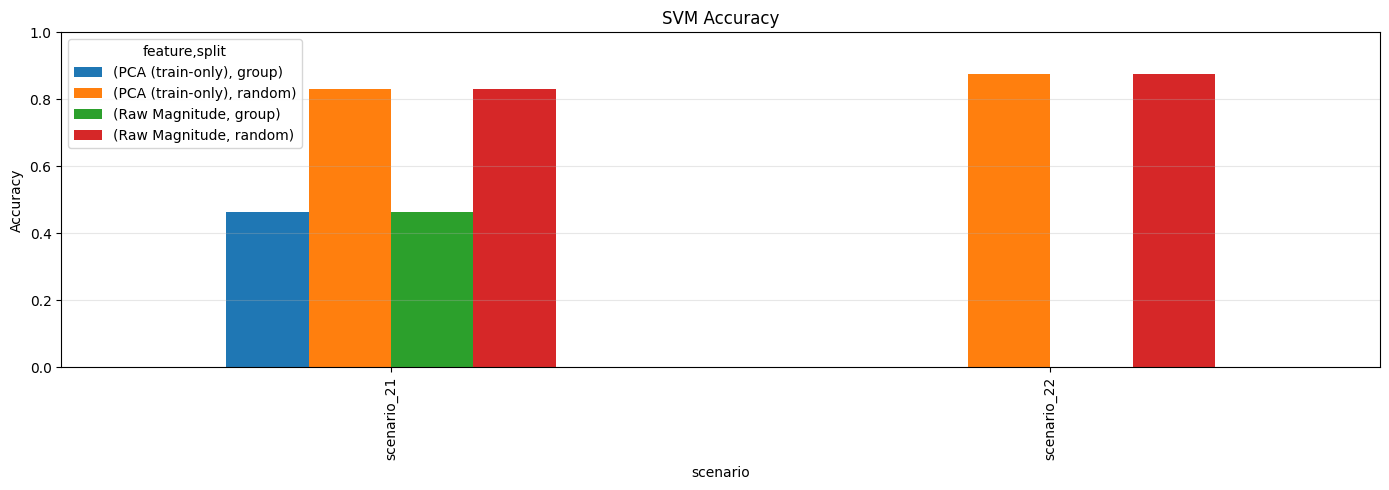

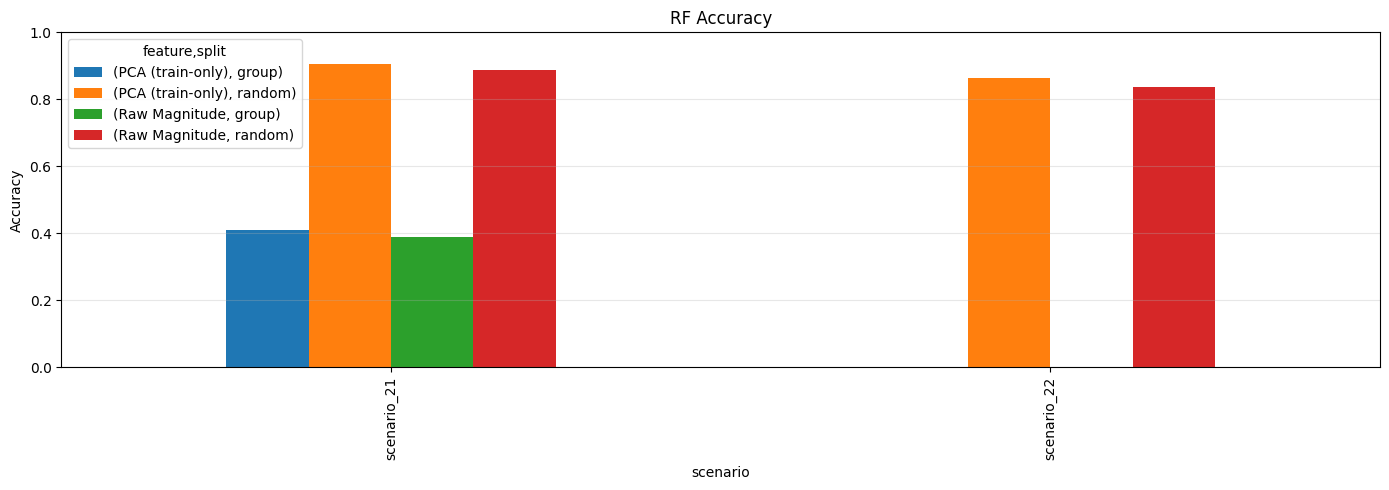


STATUS TABLE
         feature  split    scenario  status                                                          reason
PCA (train-only)  group scenario_21 trained                                                                
PCA (train-only)  group scenario_22 skipped group split unavailable (<=1 trial/group in at least one class)
PCA (train-only) random scenario_21 trained                                                                
PCA (train-only) random scenario_22 trained                                                                
   Raw Magnitude  group scenario_21 trained                                                                
   Raw Magnitude  group scenario_22 skipped group split unavailable (<=1 trial/group in at least one class)
   Raw Magnitude random scenario_21 trained                                                                
   Raw Magnitude random scenario_22 trained                                                                


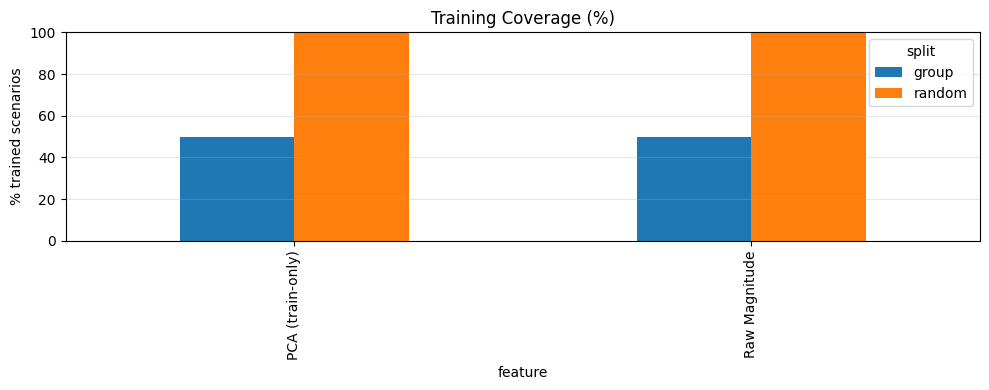


DETAILED RESULTS
         feature  split    scenario model  accuracy
PCA (train-only)  group scenario_21    RF  0.410526
PCA (train-only)  group scenario_21   SVM  0.463158
PCA (train-only) random scenario_21    RF  0.905660
PCA (train-only) random scenario_21   SVM  0.830189
PCA (train-only) random scenario_22    RF  0.864865
PCA (train-only) random scenario_22   SVM  0.875676
   Raw Magnitude  group scenario_21    RF  0.389474
   Raw Magnitude  group scenario_21   SVM  0.463158
   Raw Magnitude random scenario_21    RF  0.886792
   Raw Magnitude random scenario_21   SVM  0.830189
   Raw Magnitude random scenario_22    RF  0.837838
   Raw Magnitude random scenario_22   SVM  0.875676


In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

rows = []
for feat, split_map in model_results_all.items():
    for split, scen_map in split_map.items():
        for scenario, model_map in scen_map.items():
            for model_name in ["SVM", "RF"]:
                if model_name in model_map:
                    rows.append({
                        "feature": feat,
                        "split": split,
                        "scenario": scenario,
                        "model": model_name,
                        "accuracy": model_map[model_name]["accuracy"],
                    })

results_df = pd.DataFrame(rows)

status_rows = []
for feat, split_map in experiment_run_info.items():
    for split, scen_map in split_map.items():
        for scenario, info in scen_map.items():
            status_rows.append({
                "feature": feat,
                "split": split,
                "scenario": scenario,
                "status": info.get("status", "skipped"),
                "reason": info.get("skip_reason", ""),
            })
status_df = pd.DataFrame(status_rows)

if results_df.empty:
    print("No trained results found. Run the training cell first.")
else:
    for model_name in ["SVM", "RF"]:
        model_df = results_df[results_df["model"] == model_name]
        pivot = model_df.pivot_table(
            index="scenario",
            columns=["feature", "split"],
            values="accuracy",
            aggfunc="mean",
        )
        ax = pivot.plot(kind="bar", figsize=(14, 5), ylim=(0, 1.0), title=f"{model_name} Accuracy")
        ax.set_ylabel("Accuracy")
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

if status_df.empty:
    print("No status metadata found.")
else:
    print("\nSTATUS TABLE")
    print(status_df.sort_values(["feature", "split", "scenario"]).to_string(index=False))

    coverage = status_df.assign(trained=(status_df["status"] == "trained").astype(int))
    cov = coverage.groupby(["feature", "split"], as_index=False)["trained"].mean()
    cov["trained_pct"] = cov["trained"] * 100
    ax = cov.pivot(index="feature", columns="split", values="trained_pct").plot(
        kind="bar", figsize=(10, 4), ylim=(0, 100), title="Training Coverage (%)"
    )
    ax.set_ylabel("% trained scenarios")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\nDETAILED RESULTS")
if results_df.empty:
    print("No results.")
else:
    print(results_df.sort_values(["feature", "split", "scenario", "model"]).to_string(index=False))


#### Parameter Study: Window and Overlap Size Impact

In [26]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split

# Define window and overlap combinations to test
window_overlap_configs = []
for i in range(1, 10):
    for j in range(30, 50, 5):
        print(f"Window size: {j}, Overlap size: {i}")
        window_overlap_configs.append({"window_size": j, "overlap_size": i})


EXPLORATORY_RESULTS_MODE = True


def split_with_policy(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    test_size: float = 0.2,
    max_tries: int = 25,
    exploratory_mode: bool = True,
) -> tuple[np.ndarray, np.ndarray, str] | tuple[None, None, str]:
    group_label_df = pd.DataFrame({"label": y.values, "group": groups.values}).drop_duplicates()
    groups_per_class = group_label_df.groupby("label")["group"].nunique()

    can_use_group_split = groups_per_class.min() > 1

    if can_use_group_split:
        for seed in range(max_tries):
            gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=42 + seed)
            train_idx, test_idx = next(gss.split(X, y, groups))
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]
            if y_train.nunique() >= 2 and y_test.nunique() >= 2:
                return train_idx, test_idx, "group"

    if exploratory_mode:
        idx = np.arange(len(X))
        try:
            train_idx, test_idx = train_test_split(
                idx,
                test_size=test_size,
                random_state=42,
                stratify=y,
            )
        except ValueError:
            train_idx, test_idx = train_test_split(
                idx,
                test_size=test_size,
                random_state=42,
                stratify=None,
            )
        return np.array(train_idx), np.array(test_idx), "random-exploratory"

    return None, None, "unavailable"


# Store results for all configurations
param_study_results = {}

for config in window_overlap_configs:
    window_size = config["window_size"]
    overlap_size = config["overlap_size"]
    config_key = f"w{window_size}_o{overlap_size}"

    print(f"\n{'=' * 80}")
    print(f"Testing: Window Size = {window_size}, Overlap Size = {overlap_size}")
    print("Split policy: group when possible, else random-exploratory")
    print(f"{'=' * 80}\n")

    dataset_per_scenario_param = {}

    for scenario_key, users_map in magnitude_data.items():
        print(f"Building dataset for scenario {scenario_key}\n")
        scenario_df = build_scenario_dataset(
            users_map,
            scenario_key,
            feature_type="raw",
            window_size=window_size,
            overlap_size=overlap_size,
        )
        dataset_per_scenario_param[scenario_key] = scenario_df
        print(f"Scenario {scenario_key}: {scenario_df.shape[0]} windows")

    param_study_results[config_key] = {}

    for scenario_key, dataset in dataset_per_scenario_param.items():
        if dataset.empty:
            print(f"[SKIP] {scenario_key}: empty dataset")
            continue

        if dataset["label"].nunique() < 2:
            print(f"[SKIP] {scenario_key}: only one label present")
            continue

        feature_cols = [
            col
            for col in dataset.columns
            if col
            not in ["scenario", "user", "activity", "trial", "group_id", "window_idx", "label"]
        ]

        X = dataset[feature_cols]
        y = dataset["label"]
        groups = dataset["group_id"]

        train_idx, test_idx, split_mode = split_with_policy(
            X,
            y,
            groups,
            test_size=0.2,
            exploratory_mode=EXPLORATORY_RESULTS_MODE,
        )
        if train_idx is None:
            print(f"[SKIP] {scenario_key}: could not find valid split")
            continue

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if y_train.nunique() < 2 or y_test.nunique() < 2:
            print(f"[SKIP] {scenario_key}: split has single class in train/test")
            continue

        models = {
            "SVM": make_pipeline(
                StandardScaler(),
                SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
            ),
            "RF": RandomForestClassifier(
                n_estimators=300, random_state=42, class_weight="balanced",
            ),
        }

        param_study_results[config_key][scenario_key] = {}

        print(f"\n=== Scenario: {scenario_key} | split={split_mode} ===")
        for model_name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            f1_macro = f1_score(y_test, y_pred, average="macro")

            param_study_results[config_key][scenario_key][model_name] = {
                "accuracy": acc,
                "f1_macro": f1_macro,
                "split_mode": split_mode,
            }

            print(f"\n{model_name}: Accuracy = {acc:.4f}, F1-macro = {f1_macro:.4f}")

print(f"\n{'=' * 80}")
print("Parameter study completed!")
print(f"{'=' * 80}\n")


Window size: 30, Overlap size: 1
Window size: 35, Overlap size: 1
Window size: 40, Overlap size: 1
Window size: 45, Overlap size: 1
Window size: 30, Overlap size: 2
Window size: 35, Overlap size: 2
Window size: 40, Overlap size: 2
Window size: 45, Overlap size: 2
Window size: 30, Overlap size: 3
Window size: 35, Overlap size: 3
Window size: 40, Overlap size: 3
Window size: 45, Overlap size: 3
Window size: 30, Overlap size: 4
Window size: 35, Overlap size: 4
Window size: 40, Overlap size: 4
Window size: 45, Overlap size: 4
Window size: 30, Overlap size: 5
Window size: 35, Overlap size: 5
Window size: 40, Overlap size: 5
Window size: 45, Overlap size: 5
Window size: 30, Overlap size: 6
Window size: 35, Overlap size: 6
Window size: 40, Overlap size: 6
Window size: 45, Overlap size: 6
Window size: 30, Overlap size: 7
Window size: 35, Overlap size: 7
Window size: 40, Overlap size: 7
Window size: 45, Overlap size: 7
Window size: 30, Overlap size: 8
Window size: 35, Overlap size: 8
Window siz

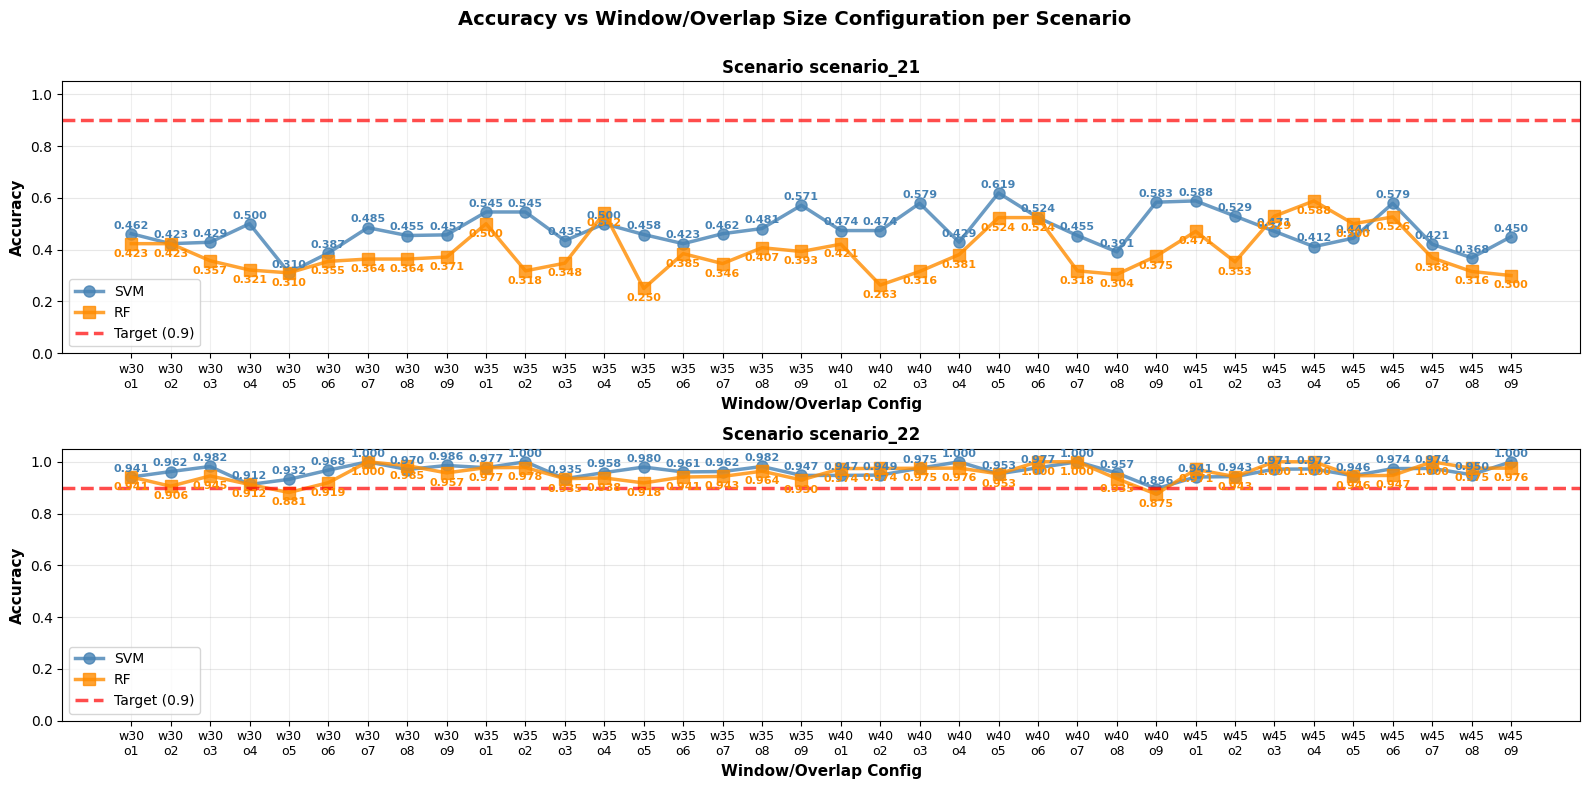


PARAMETER STUDY SUMMARY - Accuracy Results

scenario_21:
Config          SVM Accuracy       RF Accuracy        Avg Accuracy      
----------------------------------------------------------------------
w30_o1          0.4615             0.4231             0.4423            
w30_o2          0.4231             0.4231             0.4231            
w30_o3          0.4286             0.3571             0.3929            
w30_o4          0.5000             0.3214             0.4107            
w30_o5          0.3103             0.3103             0.3103            
w30_o6          0.3871             0.3548             0.3710            
w30_o7          0.4848             0.3636             0.4242            
w30_o8          0.4545             0.3636             0.4091            
w30_o9          0.4571             0.3714             0.4143            
w35_o1          0.5455             0.5000             0.5227            
w35_o2          0.5455             0.3182             0.4318        

In [27]:
# Visualization of parameter study results
if len(param_study_results) == 0:
    print("No parameter-study results available yet.")
else:
    first_key = list(param_study_results.keys())[0]
    scenario_keys_sorted = sorted(param_study_results[first_key].keys())

    if len(scenario_keys_sorted) == 0:
        print("No valid scenarios found in parameter-study results.")
    else:
        config_keys = sorted(param_study_results.keys())

        n_scenarios = len(scenario_keys_sorted)
        fig, axes = plt.subplots(n_scenarios, 1, figsize=(16, 4 * n_scenarios), squeeze=False)
        axes = axes.flatten()

        for idx, scenario_key in enumerate(scenario_keys_sorted):
            ax = axes[idx]

            svm_accs = []
            rf_accs = []
            config_labels = []

            for config_key in config_keys:
                if scenario_key in param_study_results[config_key]:
                    svm_accs.append(
                        param_study_results[config_key][scenario_key]["SVM"]["accuracy"],
                    )
                    rf_accs.append(
                        param_study_results[config_key][scenario_key]["RF"]["accuracy"],
                    )

                    # Extract window and overlap from config key
                    window = config_key.split("_")[0][1:]
                    overlap = config_key.split("_")[1][1:]
                    config_labels.append(f"w{window}\no{overlap}")

            if len(config_labels) == 0:
                ax.text(0.5, 0.5, "No valid results", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(f"Scenario {scenario_key}", fontsize=12, fontweight="bold")
                ax.set_axis_off()
                continue

            x = np.arange(len(config_labels))

            # Add line plots
            ax.plot(
                x,
                svm_accs,
                marker="o",
                linewidth=2.5,
                markersize=8,
                label="SVM",
                color="steelblue",
                alpha=0.8,
            )
            ax.plot(
                x,
                rf_accs,
                marker="s",
                linewidth=2.5,
                markersize=8,
                label="RF",
                color="darkorange",
                alpha=0.8,
            )

            # Add horizontal reference line at 0.9 accuracy
            ax.axhline(
                y=0.9,
                color="red",
                linestyle="--",
                linewidth=2.5,
                alpha=0.7,
                label="Target (0.9)",
            )

            ax.set_xlabel("Window/Overlap Config", fontsize=11, fontweight="bold")
            ax.set_ylabel("Accuracy", fontsize=11, fontweight="bold")
            ax.set_title(f"Scenario {scenario_key}", fontsize=12, fontweight="bold")
            ax.set_xticks(x)
            ax.set_xticklabels(config_labels, fontsize=9)
            ax.set_ylim([0, 1.05])
            ax.legend(fontsize=10)
            ax.grid(axis="y", alpha=0.3)
            ax.grid(axis="x", alpha=0.2)

            # Add value labels at each point
            for i, (svm_acc, rf_acc) in enumerate(zip(svm_accs, rf_accs)):
                ax.text(
                    i,
                    svm_acc + 0.02,
                    f"{svm_acc:.3f}",
                    ha="center",
                    fontsize=8,
                    color="steelblue",
                    fontweight="bold",
                )
                ax.text(
                    i,
                    rf_acc - 0.05,
                    f"{rf_acc:.3f}",
                    ha="center",
                    fontsize=8,
                    color="darkorange",
                    fontweight="bold",
                )

        plt.suptitle(
            "Accuracy vs Window/Overlap Size Configuration per Scenario",
            fontsize=14,
            fontweight="bold",
        )
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()


# Summary table
print("\n" + "=" * 100)
print("PARAMETER STUDY SUMMARY - Accuracy Results")
print("=" * 100)

if len(param_study_results) == 0:
    print("No results to summarize.")
else:
    scenario_keys_sorted = sorted(param_study_results[list(param_study_results.keys())[0]].keys())
    config_keys = sorted(param_study_results.keys())

    for scenario_key in scenario_keys_sorted:
        print(f"\n{scenario_key}:")
        print(
            f"{'Config':<15} {'SVM Accuracy':<18} {'RF Accuracy':<18} {'Avg Accuracy':<18}",
        )
        print("-" * 70)

        for config_key in config_keys:
            if scenario_key in param_study_results[config_key]:
                svm_acc = param_study_results[config_key][scenario_key]["SVM"]["accuracy"]
                rf_acc = param_study_results[config_key][scenario_key]["RF"]["accuracy"]
                avg_acc = (svm_acc + rf_acc) / 2

                print(f"{config_key:<15} {svm_acc:<18.4f} {rf_acc:<18.4f} {avg_acc:<18.4f}")
